In [39]:
import pandas as pd

# Load matches
matches = pd.read_parquet(r"Datasets/SkillCorner Premier League 24-25 data/matches_clean.parquet")

# Create team lookup table
team_lookup = pd.concat([
    matches[["home_team_id","home_team_name"]].rename(
        columns={"home_team_id":"team_id","home_team_name":"team_name"}
    ),
    matches[["away_team_id","away_team_name"]].rename(
        columns={"away_team_id":"team_id","away_team_name":"team_name"}
    )
]).drop_duplicates()

print(team_lookup.head())

   team_id              team_name
0       31      Manchester United
1      752           Ipswich Town
2       37        West Ham United
3        3  Arsenal Football Club
4       41                Everton


In [54]:
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# PANDAS DISPLAY SETTINGS
# --------------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

# ==================================================
# 1. LOAD ALL MATCH EVENT FILES
# ==================================================
folder = Path(r"Datasets\SkillCorner Premier League 24-25 data\dynamic_events_pl_24\dynamic")
dfs = [pd.read_parquet(file) for file in folder.glob("*.parquet")]
events = pd.concat(dfs, ignore_index=True)

print("Total events loaded:", len(events))
print("Unique matches:", events["match_id"].nunique())

# ==================================================
# 2. FILTER PASSING OPTIONS
# ==================================================
passing_options = events[events["event_type"] == "passing_option"].copy()
print("\nPassing option rows:", len(passing_options))

# ==================================================
# 3. KEEP IMPORTANT COLUMNS & CLEAN
# ==================================================
passing_options = passing_options[
    [
        "match_id",
        "associated_player_possession_event_id",
        "player_id",
        "player_name",
        "passing_option_score",
        "xthreat",
        "player_targeted_xpass_completion",
        "targeted"
    ]
].dropna(subset=["passing_option_score"])

passing_options["xthreat"] = pd.to_numeric(passing_options["xthreat"], errors="coerce").fillna(0)
passing_options["player_targeted_xpass_completion"] = pd.to_numeric(
    passing_options["player_targeted_xpass_completion"], errors="coerce"
).fillna(1)

print("\nRows after cleaning:", len(passing_options))

# ==================================================
# 4. COUNT OPTIONS PER DECISION
# ==================================================
option_counts = (
    passing_options
    .groupby(["match_id", "associated_player_possession_event_id"])
    .size()
    .reset_index(name="n_options")
)
print("\nDecision moments:", len(option_counts))

# ==================================================
# 5. REMOVE TRIVIAL DECISIONS
# ==================================================
option_counts = option_counts[option_counts["n_options"] >= 2]
passing_options = passing_options.merge(
    option_counts[["match_id", "associated_player_possession_event_id"]],
    on=["match_id", "associated_player_possession_event_id"]
)
print("\nPassing options after filtering trivial decisions:", len(passing_options))

# ==================================================
# 6. PASS VALUE
# ==================================================
passing_options["pass_value"] = (
    passing_options["passing_option_score"]
    * passing_options["xthreat"]
    * passing_options["player_targeted_xpass_completion"]
)

# ==================================================
# 7. BEST OPTION PER DECISION
# ==================================================
best_option = (
    passing_options
    .groupby(["match_id", "associated_player_possession_event_id"])
    .agg(
        best_option_score=("passing_option_score", "max"),
        best_xThreat_available=("xthreat", "max"),
        best_pass_value=("pass_value", "max"),
        avg_option_quality=("passing_option_score", "mean"),
        avg_option_xThreat=("xthreat", "mean")
    )
    .reset_index()
)

# ==================================================
# 8. IDENTIFY CHOSEN PASSES
# ==================================================
chosen = passing_options[passing_options["targeted"] == True].copy()
chosen = chosen[
    [
        "match_id",
        "associated_player_possession_event_id",
        "player_id",
        "player_name",
        "passing_option_score",
        "xthreat",
        "pass_value"
    ]
].rename(columns={
    "passing_option_score": "chosen_option_score",
    "xthreat": "chosen_xThreat",
    "pass_value": "chosen_pass_value"
})

# ==================================================
# 9. MERGE DECISION DATA
# ==================================================
decisions = chosen.merge(
    best_option,
    on=["match_id", "associated_player_possession_event_id"]
)

# ==================================================
# 10. COMPUTE DECISION METRICS
# ==================================================
decisions["decision_quality"] = decisions["chosen_option_score"] / decisions["best_option_score"]
decisions["value_decision_quality"] = decisions["chosen_pass_value"] / decisions["best_pass_value"]
decisions["creativity"] = decisions["chosen_xThreat"] / decisions["best_xThreat_available"]
decisions["risk_taken"] = decisions["best_option_score"] - decisions["chosen_option_score"]
decisions["xThreat_gain"] = decisions["chosen_xThreat"] - decisions["best_xThreat_available"]

# ==================================================
# 11. AGGREGATE PLAYER METRICS
# ==================================================
players = (
    decisions
    .groupby(["player_id", "player_name"])
    .agg(
        passes=("decision_quality", "count"),
        decision_quality=("decision_quality", "mean"),
        value_decision_quality=("value_decision_quality", "mean"),
        creativity=("creativity", "mean"),
        avg_xThreat_created=("chosen_xThreat", "mean"),
        avg_xThreat_gain=("xThreat_gain", "mean"),
        total_xThreat_gain=("xThreat_gain", "sum"),
        avg_option_quality=("avg_option_quality", "mean"),
        risk_taken=("risk_taken", "sum")  # sum for per90 calculation
    )
    .reset_index()
)
players = players[players["passes"] > 200]
print("Players with 200+ decisions:", len(players))

# ==================================================
# 12. LOAD PLAYER POSITION + MINUTES
# ==================================================
players_match = pd.read_parquet(r"Datasets/SkillCorner Premier League 24-25 data/players_match.parquet")
players_match["player_id"] = players_match["id"]
players_match["player_name"] = players_match["short_name"]
players_match["position"] = players_match["player_role_acronym"]
players_match["position_group"] = players_match["player_role_position_group"]

position_counts = (
    players_match
    .groupby(["player_id","player_name","team_id","position","position_group"])
    .size()
    .reset_index(name="matches_at_position")
)

# ==================================================
# 12a. HANDLE SUBSTITUTES AND SECOND MAIN POSITION
# ==================================================
position_counts_sorted = position_counts.sort_values(["player_id","matches_at_position"], ascending=[True, False])

def get_main_and_group(df):
    main_pos = df.iloc[0]["position"]
    sub_flag = 0
    final_pos = main_pos
    final_group = df.iloc[0]["position_group"]
    if main_pos == "SUB":
        sub_flag = 1
        if len(df) > 1:
            final_pos = df.iloc[1]["position"]
            final_group = df.iloc[1]["position_group"]
        else:
            final_pos = "SUB"
            final_group = "SUB"
    # Special case for GK
    if final_pos == "GK":
        final_group = "Goalkeeper"
    return pd.Series({"main_position_adjusted": final_pos, "SUB": sub_flag, "position_group_adjusted": final_group})

main_positions_adjusted = position_counts_sorted.groupby("player_id").apply(get_main_and_group).reset_index()

# ==================================================
# Player info with minutes
# ==================================================
player_main_position = position_counts.sort_values("matches_at_position", ascending=False).drop_duplicates("player_id")
player_main_position = player_main_position[["player_id","team_id","position","position_group"]].rename(columns={"position":"main_position"})

minutes_df = (
    players_match
    .groupby("player_id")
    .agg(
        minutes_played_total=("playing_time_total_minutes_played","sum"),
        minutes_regular_time=("playing_time_total_minutes_played_regular_time","sum")
    )
    .reset_index()
)
minutes_df["per90_factor"] = minutes_df["minutes_played_total"] / 90

player_info = player_main_position.merge(minutes_df, on="player_id", how="left")
player_info = player_info.merge(main_positions_adjusted, on="player_id", how="left")
player_info["main_position"] = player_info["main_position_adjusted"]
player_info["position_group"] = player_info["position_group_adjusted"]
player_info.drop(columns=["main_position_adjusted","position_group_adjusted"], inplace=True)

# ==================================================
# 13. LOAD TEAM NAMES
# ==================================================
matches = pd.read_parquet(r"Datasets/SkillCorner Premier League 24-25 data/matches_clean.parquet")
team_lookup = pd.concat([
    matches[["home_team_id","home_team_name"]].rename(columns={"home_team_id":"team_id","home_team_name":"team_name"}),
    matches[["away_team_id","away_team_name"]].rename(columns={"away_team_id":"team_id","away_team_name":"team_name"})
]).drop_duplicates()

player_info = player_info.merge(team_lookup, on="team_id", how="left")

# ==================================================
# 14. MERGE PLAYER METRICS WITH INFO
# ==================================================
players = players.merge(player_info, on="player_id", how="left")

# ==================================================
# 15. CALCULATE PER 90 METRICS (only sums/counts)
# ==================================================
players["passes_per90"] = players["passes"] / players["per90_factor"]
players["total_xThreat_gain_per90"] = players["total_xThreat_gain"] / players["per90_factor"]
players["risk_taken_per90"] = players["risk_taken"] / players["per90_factor"]

# ==================================================
# 16. FINAL COLUMN ORDER
# ==================================================
columns_order = [
    "player_id","player_name","team_id","team_name",
    "main_position","SUB","position_group",
    "passes","passes_per90",
    "decision_quality","value_decision_quality","creativity",
    "avg_xThreat_created","avg_xThreat_gain",
    "total_xThreat_gain","total_xThreat_gain_per90",
    "avg_option_quality","risk_taken","risk_taken_per90",
    "minutes_played_total","minutes_regular_time","per90_factor"
]
players = players[columns_order]

Total events loaded: 1811078
Unique matches: 378

Passing option rows: 939059

Rows after cleaning: 939058

Decision moments: 330426

Passing options after filtering trivial decisions: 893754
Players with 200+ decisions: 374


C:\Users\vicky\AppData\Local\Temp\ipykernel_38192\880558068.py:195: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  main_positions_adjusted = position_counts_sorted.groupby("player_id").apply(get_main_and_group).reset_index()


In [55]:
# Top decision makers:
players.sort_values("decision_quality", ascending=False).head(10)

,player_id,player_name,team_id,team_name,main_position,SUB,position_group,passes,passes_per90,decision_quality,value_decision_quality,creativity,avg_xThreat_created,avg_xThreat_gain,total_xThreat_gain,total_xThreat_gain_per90,avg_option_quality,risk_taken,risk_taken_per90,minutes_played_total,minutes_regular_time,per90_factor
136,12476,T. Mings,39,Aston Villa,LCB,0,Central Defender,411,29.941477,0.966019,0.360993,0.329958,0.001612,-0.004962,-2.0394,-0.148571,0.827209,12.3500,0.899701,1235.41,1235.41,13.726778
218,19584,G. Vicario,44,Tottenham Hotspur,GK,0,Goalkeeper,345,12.958395,0.963644,0.065154,0.057936,0.000032,-0.001702,-0.5872,-0.022056,0.837188,11.3649,0.426872,2396.13,2396.13,26.623667
299,32773,E. Agbadou,52,Wolverhampton Wanderers,CB,0,Central Defender,543,31.381640,0.961676,0.402437,0.373063,0.000953,-0.003090,-1.6778,-0.096965,0.827397,18.7334,1.082661,1557.28,1557.28,17.303111
124,12257,A. Disasi,49,Chelsea,RB,1,Full Back,405,38.527397,0.960605,0.378058,0.345034,0.002598,-0.006107,-2.4735,-0.235303,0.831634,14.2856,1.358980,946.08,946.08,10.512000
44,5907,K. Trippier,32,Newcastle United,RB,0,Full Back,697,43.329304,0.957711,0.485787,0.447130,0.004110,-0.010175,-7.0922,-0.440890,0.837060,26.6017,1.653706,1447.75,1447.75,16.086111
111,12098,R. James,49,Chelsea,RB,0,Full Back,489,36.378214,0.957381,0.516528,0.481113,0.003565,-0.006697,-3.2748,-0.243622,0.833335,18.5701,1.381487,1209.79,1209.79,13.442111
337,64677,J. Kiwior,3,Arsenal Football Club,LCB,1,Central Defender,508,36.152867,0.957242,0.389321,0.353116,0.002196,-0.006552,-3.3284,-0.236872,0.832559,19.6283,1.396888,1264.63,1264.63,14.051444
154,12895,K. Tsimikas,2,Liverpool Football Club,LB,0,Full Back,368,35.022788,0.955244,0.483434,0.444348,0.005673,-0.009741,-3.5848,-0.341168,0.825934,14.6854,1.397619,945.67,945.67,10.507444
150,12794,V. Coufal,37,West Ham United,RB,0,Full Back,349,25.873360,0.955008,0.468260,0.435738,0.003759,-0.008308,-2.8994,-0.214949,0.832535,14.1587,1.049665,1213.99,1213.99,13.488778
195,18568,M. Cash,39,Aston Villa,RB,0,Full Back,607,23.890322,0.954806,0.479874,0.445188,0.005755,-0.009956,-6.0430,-0.237841,0.825858,24.2797,0.955601,2286.70,2286.70,25.407778


<Figure size 1200x600 with 0 Axes>

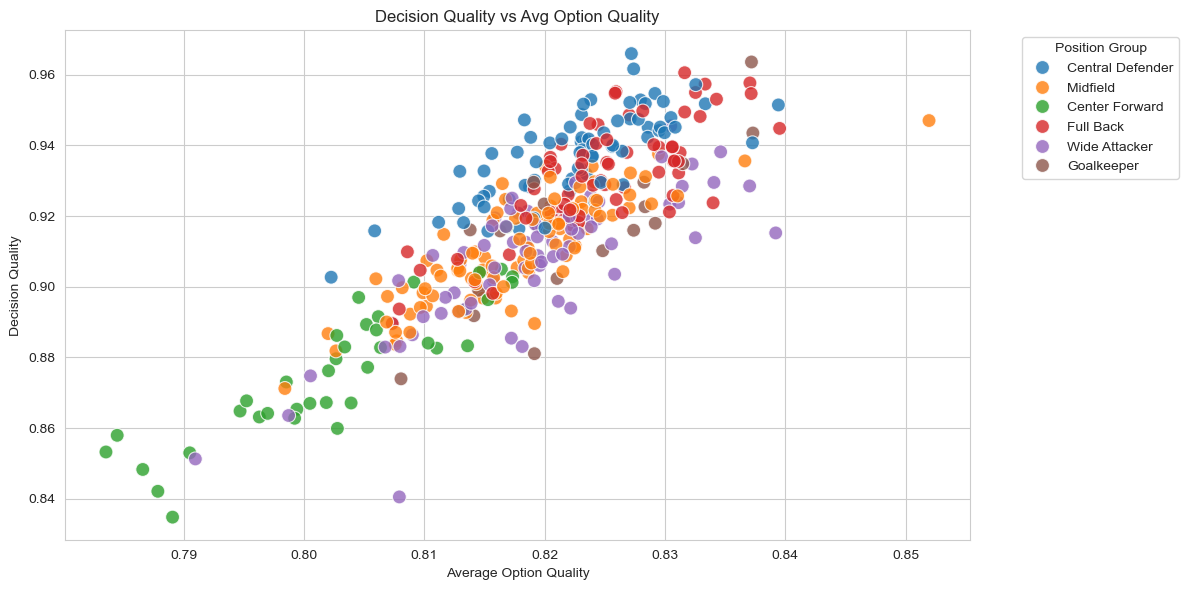

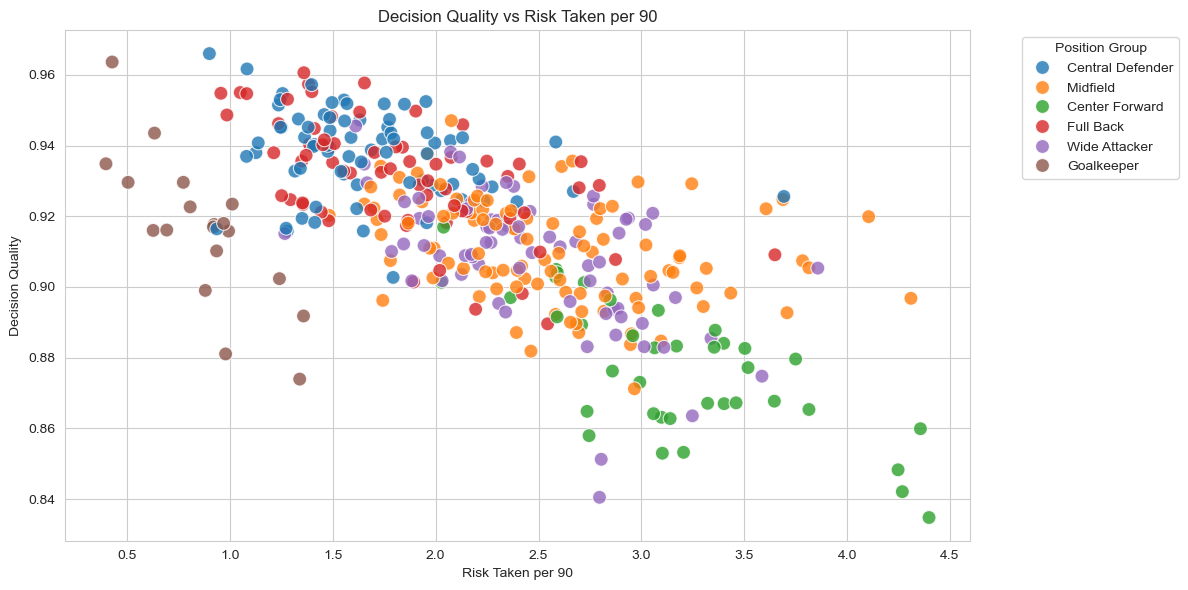

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# ==================================================
# 1. decision_quality vs avg_option_quality
# ==================================================
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=players,
    x="avg_option_quality",
    y="decision_quality",
    hue="position_group",
    palette="tab10",
    s=100,
    alpha=0.8
)
plt.title("Decision Quality vs Avg Option Quality")
plt.xlabel("Average Option Quality")
plt.ylabel("Decision Quality")
plt.legend(title="Position Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==================================================
# 2. decision_quality vs risk_taken_per90
# ==================================================
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=players,
    x="risk_taken_per90",
    y="decision_quality",
    hue="position_group",
    palette="tab10",
    s=100,
    alpha=0.8
)
plt.title("Decision Quality vs Risk Taken per 90")
plt.xlabel("Risk Taken per 90")
plt.ylabel("Decision Quality")
plt.legend(title="Position Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==================================================
# 2. decision_quality vs risk_taken_per90
# ==================================================
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=players,
    x="risk_taken_per90",
    y="# ==================================================
# 2. decision_quality vs risk_taken_per90
# ==================================================
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=players,
    x="risk_taken_per90",
    y="decision_quality",
    hue="position_group",
    palette="tab10",
    s=100,
    alpha=0.8
)
plt.title("Decision Quality vs Risk Taken per 90")
plt.xlabel("Risk Taken per 90")
plt.ylabel("Decision Quality")
plt.legend(title="Position Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()",
    hue="position_group",
    palette="tab10",
    s=100,
    alpha=0.8
)
plt.title("Decision Quality vs Risk Taken per 90")
plt.xlabel("Risk Taken per 90")
plt.ylabel("Decision Quality")
plt.legend(title="Position Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()